<h1 style="color: #CEDDF4;">DEPI Round 4, MS Data Engineer and AI Track</h1>
<h2 style="color: #CEDDF4;" >Final Project: Gold and Oil Prediction System</h2>
<h3 style="color: #CEDDF4;" > Part (2): Python Code for Machine Learning and Modeling</h3>
<h4 style="color: #CEDDF4;" > 2.1: ML for Gold Price</h4>

In this section, we aim to forecast gold prices over a specified timeframe. For the scope of this academic exercise, the prediction window is set from **January 1, 2026, to April 30, 2026**. 

To evaluate performance, we will implement and compare two distinct modeling approaches:

*   **Top Features Model:** This approach utilizes a curated subset of variables identified as having the most significant impact on gold prices. The exact number of features retained is an adjustable hyperparameter that can be optimized during the model's fine-tuning phase.
*   **Full Feature Model:** This baseline approach incorporates all available features within the dataset to generate predictions.

<h4 style="color: #CEDDF4;" >1. Import Libraries</h4>

In [1]:
import os
import math
from pathlib import Path
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
import lightgbm as lgb
import joblib
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import numpy as np
import matplotlib.ticker as mticker

In [2]:
base_dir = Path.cwd()
#raw data path to contain all raw files gathered either manually, web scraping or APIs
raw_data_dir=base_dir/'raw data'
#cleaned data path, will be separated into two main folders which are: market data (contains the data with daily logs) and macroeconomic data
##cleaned market data
cleaned_market_data_dir=base_dir/'cleaned data'/'market_data'
##cleaned macroeconomic data
cleaned_macro_data_dir=base_dir/'cleaned data'/'macroeconomic_data'
##ai modeling data
ai_data_dir=base_dir/'ai model'

<h4 style="color: #CEDDF4;" >1.1 Data Loading and Processing</h4>

In [13]:
def make_tag(filename):
    tag = filename
    tag = tag.replace('global_', '').replace('usa_', '').replace('egy_', '')
    tag = tag.replace('_prices', '').replace('_price', '').replace('_index', '').replace('_rate', '')
    return tag

In [14]:
#the below function is made to call all the date within specific folder (market / macro) and make final cleaning and sorting methods on it to be using in our master table
def loading(filename, tag, dir):
    df = pd.read_csv(dir / f"{filename}.csv")
    df = df.drop(columns=['id', 'region', 'ticker'], errors='ignore')
    df['date'] = pd.to_datetime(df['date'], dayfirst=False, format='mixed', errors='coerce')
    df = df.rename(columns={c: f"{tag}_{c}" for c in df.columns if c != 'date'})
    df = df.drop_duplicates(subset='date')
    df = df.set_index('date')
    full_dates = pd.date_range(start='2016-01-01', end='2026-04-30', freq='D')
    df = df.reindex(full_dates)
    first_valid = df.first_valid_index()
    if first_valid is not None:
        df.loc[:first_valid] = df.loc[:first_valid].bfill()
    df = df.ffill()
    df = df.reset_index().rename(columns={'index': 'date'})
    return df

In [15]:
#the below is for loop to iterate over all files within cleaned market data 
all_market_df=[]
for filepath in cleaned_market_data_dir.glob("*.csv"):
    raw_file_name = filepath.stem
    tag = make_tag(raw_file_name)
    new_df = loading(raw_file_name, tag, cleaned_market_data_dir)
    all_market_df.append(new_df)

In [16]:
#the below is a minor tweak to egy_cpi file in macroeconomic data folder which is obtained via data_cleaning.ipynb section 2.1
egy_cpi=pd.read_csv(cleaned_macro_data_dir/'egy_cpi.csv')
egy_cpi=egy_cpi.rename(columns={'year':'date'})
egy_cpi.to_csv(cleaned_macro_data_dir/'egy_cpi.csv',index=False)

In [17]:
#the below is for loop to iterate over all files within cleaned macroeconomic data data 
all_macro_df=[]
for filepath in cleaned_macro_data_dir.glob("*.csv"):
    raw_file_name = filepath.stem
    tag = make_tag(raw_file_name)
    new_df = loading(raw_file_name, tag, cleaned_macro_data_dir)
    all_macro_df.append(new_df)

In [18]:
#get all dataframes from previous steps in one dataframe as reduce function takes only one argument
all_df = all_macro_df + all_market_df
#create the master table and make data column the primary key for merging process
master_table = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), all_df)
master_table = master_table.dropna(axis=1, how='all')

In [19]:
#saving the master table into a csv file to be used in the modeling
master_table.to_csv(ai_data_dir/'master_table.csv',index=False)

In [20]:
df=pd.read_csv(ai_data_dir/'master_table.csv')

In [21]:
df = df.bfill().ffill()

In [22]:
df.to_csv(ai_data_dir/'new_master_table.csv',index=False)

<h4 style="color: #CEDDF4;" >2. Data Reading and Processing</h4>

In [13]:
df=pd.read_csv(ai_data_dir/'new_master_table.csv')

<h4 style="color: #CEDDF4;" >2.1 Handling data </h4>

In [14]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce')
data = df[df['date'] <= '2025-08-30']
data_clean = data.copy()

for col in data_clean.columns:
    if data_clean[col].dtype == "object":
        data_clean[col] = data_clean[col].astype(str).str.replace('%', '', regex=False)
        data_clean[col] = pd.to_numeric(data_clean[col], errors='ignore')
data_clean = data_clean.apply(pd.to_numeric, errors='coerce')
data_clean = data_clean.dropna(axis=1, how='all')

<h4 style="color: #CEDDF4;" >2.2 Data Correlation</h4>

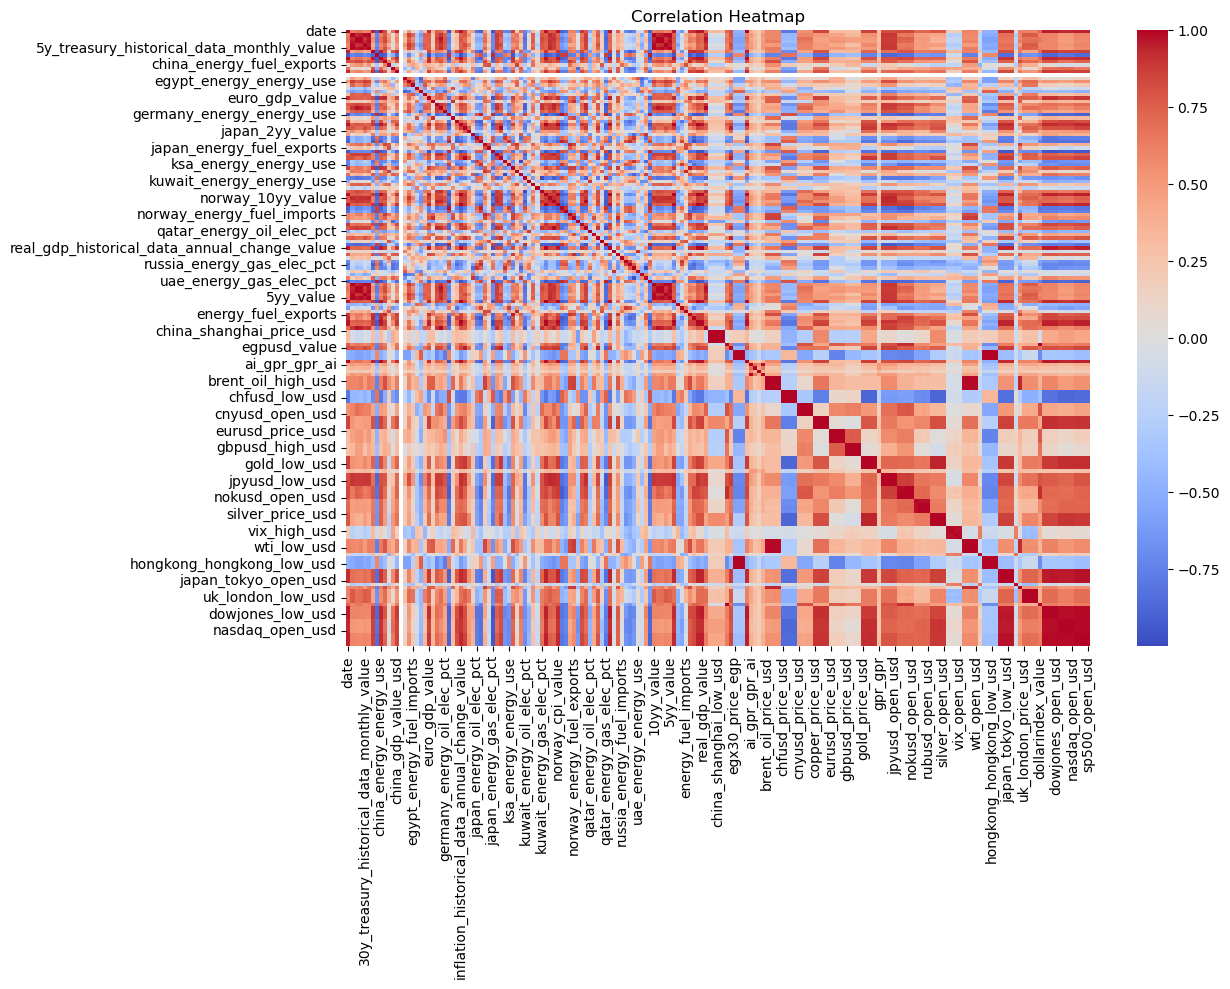

In [15]:
corr = data_clean.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.savefig(ai_data_dir/"correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

<h4 style="color: #CEDDF4;" >2.3 Saving Data Correlation</h4>

In [16]:
data_clean.to_csv(ai_data_dir/'stats.csv',index=False)

<h4 style="color: #CEDDF4;" >3. Gold Price Prediction</h4>

<h4 style="color: #CEDDF4;" > 3.1 Setup</h4>

In [17]:
# define target variable
target_col = 'gold_price_usd'
# avoid modifying original dataset
df = pd.read_csv(ai_data_dir / 'new_master_table.csv')  

<h4 style="color: #CEDDF4;" > 3.2 Time preprocessing</h4>


In [18]:
df['date'] = pd.to_datetime(df['date'], dayfirst=False, format='mixed', errors='coerce')  # ← False
df = df.sort_values('date')

<h4 style="color: #CEDDF4;" > 3.3 Remove leakage features</h4>

In [19]:
leakage_keywords = [
    '_open_', '_high_', '_low_',
    'gpr_event',
    'ai_gpr_Unnamed',
    'gold_price_oz_egp',
    'cbe_inflations_headline_inflation_yy',
    'cbe_inflations_core_inflation_yy'
]
### remove features that leak future info
df = df.drop(columns=[
    c for c in df.columns
    if any(k in c for k in leakage_keywords)
], errors='ignore')  


<h4 style="color: #CEDDF4;" > 3.4 Macro feature engineering</h4>


In [20]:
df['real_rate_us'] = df['usd_fedfunds_value'] - df['cpi_value']  # US real interest rate
df['real_rate_eu'] = df['euro_interest_value'] - df['euro_inflation_value']  # EU real interest rate

df['oil_x_dxy'] = df['brent_oil_price_usd'] * df['dollarindex_value']  # oil-dollar interaction
df['vix_x_dxy'] = df['vix_price_usd'] * df['dollarindex_value']  # volatility-dollar interaction

df['sp500_mom'] = df['sp500_price_usd'].pct_change()  # market momentum

C:\Users\HMSY\AppData\Local\Temp\ipykernel_20056\2789997807.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['real_rate_us'] = df['usd_fedfunds_value'] - df['cpi_value']  # US real interest rate
C:\Users\HMSY\AppData\Local\Temp\ipykernel_20056\2789997807.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['real_rate_eu'] = df['euro_interest_value'] - df['euro_inflation_value']  # EU real interest rate
C:\Users\HMSY\AppData\Local\Temp\ipykernel_20056\2789997807.py:4: PerformanceWarning: DataFrame is highly fragmented.  T

<h4 style="color: #CEDDF4;" > 3.5 Feature engineering</h4>



In [21]:
df['log_price'] = np.log(df[target_col])  # log transformation for stability
df['return'] = df['log_price'].diff()  # compute returns

df['target'] = df['return'].rolling(5).mean().shift(-1)  # future smoothed return target
df['target'] = df['target'].clip(-0.03, 0.03)  # limit extreme values


C:\Users\HMSY\AppData\Local\Temp\ipykernel_20056\2395862248.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['log_price'] = np.log(df[target_col])  # log transformation for stability
C:\Users\HMSY\AppData\Local\Temp\ipykernel_20056\2395862248.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['return'] = df['log_price'].diff()  # compute returns
C:\Users\HMSY\AppData\Local\Temp\ipykernel_20056\2395862248.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many

<h4 style="color: #CEDDF4;" > 3.6 Lag features</h4>


In [22]:
for lag in [1,2,3,5,10,20]:
    df[f'return_lag_{lag}'] = df['return'].shift(lag)  # past returns

df['log_price_lag1'] = df['log_price'].shift(1)  # previous price level

C:\Users\HMSY\AppData\Local\Temp\ipykernel_20056\1738934450.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'return_lag_{lag}'] = df['return'].shift(lag)  # past returns
C:\Users\HMSY\AppData\Local\Temp\ipykernel_20056\1738934450.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'return_lag_{lag}'] = df['return'].shift(lag)  # past returns
C:\Users\HMSY\AppData\Local\Temp\ipykernel_20056\1738934450.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

<h4 style="color: #CEDDF4;" > 3.7 Volatility and momentum</h4>


In [23]:
df['vol_7'] = df['return'].rolling(7).std().shift(1)  # short volatility
df['vol_20'] = df['return'].rolling(20).std().shift(1)  # long volatility
df['mom_7'] = df['return'].rolling(7).mean().shift(1)  # short momentum

df['price_trend_7'] = df[target_col].rolling(7).mean().shift(1)  # trend feature

C:\Users\HMSY\AppData\Local\Temp\ipykernel_20056\1490758434.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['vol_7'] = df['return'].rolling(7).std().shift(1)  # short volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_20056\1490758434.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['vol_20'] = df['return'].rolling(20).std().shift(1)  # long volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_20056\1490758434.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame

<h4 style="color: #CEDDF4;" > 3.8 Data cleaning</h4>


In [24]:
df = df.dropna()  # remove missing values

<h4 style="color: #CEDDF4;" > 3.9 Feature selection</h4>


In [25]:
features = [c for c in df.columns if c not in ['date', target_col, 'target']]  # model inputs

<h4 style="color: #CEDDF4;" > 3.10 Train/test split</h4>


In [26]:
train = df[df['date'] <= '2025-12-31']  # training period
test = df[ (df['date'] > '2025-12-31') & (df['date'] <= '2026-04-30') ] #testing period

X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']

<h4 style="color: #CEDDF4;" > 3.11 time series Cross-validation</h4>


In [27]:
tscv = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv.split(X_train)):

    model_cv = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6
    )

    model_cv.fit(X_train.iloc[tr], y_train.iloc[tr])  # train fold model

    pred = model_cv.predict(X_train.iloc[val])  # validation prediction

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train.iloc[val], pred))  # error
    print("DIR:", np.mean(np.sign(y_train.iloc[val]) == np.sign(pred)))  # direction accuracy


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001837 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9720
[LightGBM] [Info] Number of data points in the train set: 607, number of used features: 136
[LightGBM] [Info] Start training from score 0.000296
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

<h4 style="color: #CEDDF4;" > 3.12 Full Model training</h4>


In [28]:
model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16470
[LightGBM] [Info] Number of data points in the train set: 3632, number of used features: 137
[LightGBM] [Info] Start training from score 0.000381


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;" > 3.13 Feature selection</h4>


In [29]:
selector = SelectFromModel(model, threshold='median', prefit=True)

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

model.fit(X_train_sel, y_train)

with open(ai_data_dir/'models'/"standalone_gold_price_full_model.pkl", "wb") as f:
    pickle.dump(model, f)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001790 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15012
[LightGBM] [Info] Number of data points in the train set: 3632, number of used features: 69
[LightGBM] [Info] Start training from score 0.000381


<h4 style="color: #CEDDF4;" > 3.14 Prediction (full model)</h4>


In [30]:
pred_returns = model.predict(X_test_sel)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<h4 style="color: #CEDDF4;" > 3.15 Price Prediction (full model)</h4>


In [31]:
start_price = train[target_col].iloc[-1]

prices = [start_price]

for r in pred_returns:
    prices.append(prices[-1] * np.exp(r))

prices = prices[1:]

test = test.copy()
test['pred_price'] = prices

<h4 style="color: #CEDDF4;" > 3.16 Evaluation (full model)</h4>



In [32]:
mae = mean_absolute_error(test[target_col], test['pred_price'])
direction = np.mean(np.sign(test['target']) == np.sign(pred_returns))

print("Full Model MAE:", mae)
print("Full Model Direction:", direction)

Full Model MAE: 271.7083446078239
Full Model Direction: 0.8151260504201681


<h4 style="color: #CEDDF4;" > 3.17 Top Features Extraction</h4>


In [33]:
importance_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

importance_model.fit(X_train, y_train)

importance = pd.Series(
    importance_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003239 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16470
[LightGBM] [Info] Number of data points in the train set: 3632, number of used features: 137
[LightGBM] [Info] Start training from score 0.000381


<h4 style="color: #CEDDF4;" > 3.18 Top Features selection</h4>



In [34]:
top_k = 15
top_features = importance.head(top_k).index.tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

<h4 style="color: #CEDDF4;" > 3.19 Top model training</h4>



In [35]:
top_model = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',

    n_estimators=3000,
    learning_rate=0.02,

    num_leaves=128,
    max_depth=10,

    min_child_samples=10,
    min_child_weight=1e-3,

    subsample=0.9,
    subsample_freq=1,

    colsample_bytree=0.9,

    reg_alpha=0.1,
    reg_lambda=0.3,

    random_state=42
)

top_model.fit(X_train_top, y_train)

#model saving into pickle file

with open(ai_data_dir/'models'/"standalone_gold_price_top_features_model.pkl", "wb") as f:
    pickle.dump(top_model, f)

pred_top = top_model.predict(X_test_top)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000398 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 3632, number of used features: 15
[LightGBM] [Info] Start training from score 0.000381
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

<h4 style="color: #CEDDF4;" > 3.20 Price Prediction (top model)</h4>



In [36]:
prices_top = [start_price]

for r in pred_top:
    prices_top.append(prices_top[-1] * np.exp(r))

prices_top = prices_top[1:]

test['pred_price_top'] = prices_top

<h4 style="color: #CEDDF4;" > 3.21 Evaluation (top model)</h4>



In [37]:
mae_top = mean_absolute_error(test[target_col], test['pred_price_top'])
direction_top = np.mean(np.sign(test['target']) == np.sign(pred_top))

print("Top Features Model MAE:", mae_top)
print("Top Features Model Direction:", direction_top)

Top Features Model MAE: 159.71303946243134
Top Features Model Direction: 0.8235294117647058


<h4 style="color: #CEDDF4;" > 3.22 Model Comparison Using Visualizations</h4>

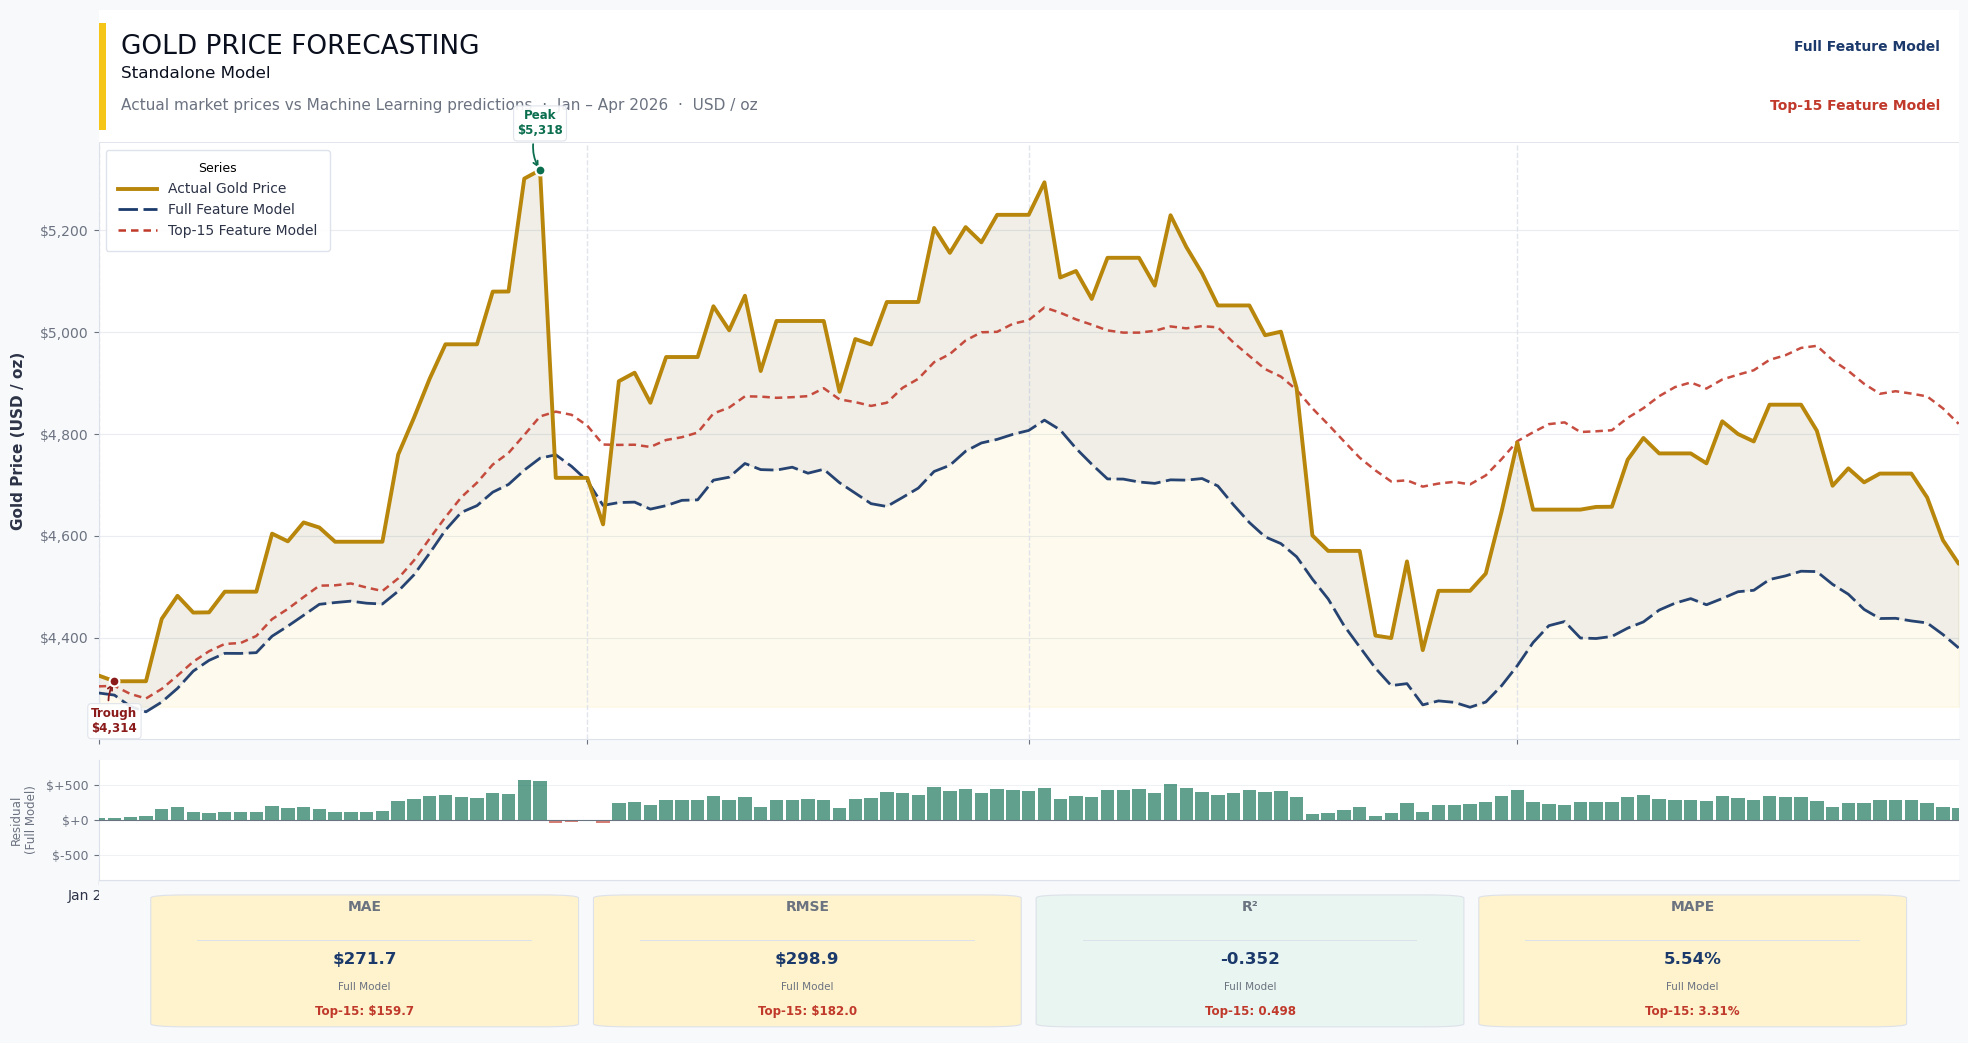

In [38]:
# ── KPI helper ────────────────────────────────────────────────────────────────
def kpis(a, p):
    mae  = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    r2   = 1 - np.sum((a - p) ** 2) / np.sum((a - a.mean()) ** 2)
    mape = np.mean(np.abs((a - p) / a)) * 100
    return mae, rmse, r2, mape

plot_df    = test.sort_values('date').copy()
dates      = plot_df['date'].values
actual     = plot_df[target_col].values
full_pred  = plot_df['pred_price'].values
top_pred   = plot_df['pred_price_top'].values

mae_f, rmse_f, r2_f, mape_f = kpis(actual, full_pred)
mae_t, rmse_t, r2_t, mape_t = kpis(actual, top_pred)

# ── Palette ───────────────────────────────────────────────────────────────────
PAGE, WHITE, BORDER, GRID = '#F8F9FB', '#FFFFFF', '#DDE1E9', '#EAECF2'
GOLD_DARK, GOLD_FILL      = '#B8860B', '#F5C518'
NAVY, CRIMSON             = '#1B3A6B', '#C0392B'
TEXT_H, TEXT_B, TEXT_M    = '#0A0F1E', '#2C3347', '#6B7280'
GREEN_KPI, GREEN_BG       = '#0B6E4F', '#E8F5F0'
RED_KPI                   = '#8B1A1A'
AMBER_KPI, AMBER_BG       = '#7A4F00', '#FEF3CD'

# ── Figure & layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11), facecolor=PAGE)
outer = gridspec.GridSpec(3, 1, height_ratios=[0.13, 0.72, 0.15],
                          hspace=0, left=0.04, right=0.97, top=0.97, bottom=0.04)

# ── Header band ───────────────────────────────────────────────────────────────
ax_head = fig.add_subplot(outer[0])
ax_head.set_facecolor(WHITE)
ax_head.set_xlim(0,1); ax_head.set_ylim(0,1)
for sp in ax_head.spines.values(): sp.set_visible(False)
ax_head.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_head.add_patch(mpatches.FancyBboxPatch((0,0.1),0.004,0.8,
    boxstyle='square,pad=0', fc=GOLD_FILL, ec='none',
    transform=ax_head.transAxes, clip_on=False))
ax_head.text(0.012, 0.72, 'GOLD PRICE FORECASTING', transform=ax_head.transAxes,
             fontsize=19, fontweight='normal', color=TEXT_H, va='center')
ax_head.text(0.012, 0.52, 'Standalone Model', transform=ax_head.transAxes,
             fontsize=12, fontweight='normal', color=TEXT_H, va='center')
ax_head.text(0.012, 0.28,
    'Actual market prices vs Machine Learning predictions  ·  Jan – Apr 2026  ·  USD / oz',
    transform=ax_head.transAxes, fontsize=11, color=TEXT_M, va='center')
ax_head.text(0.99, 0.72, 'Full Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=NAVY, ha='right', va='center')
ax_head.text(0.99, 0.28, f'Top-{top_k} Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=CRIMSON, ha='right', va='center')
ax_head.axhline(0, color=BORDER, linewidth=1.2)

# ── Chart + residual ──────────────────────────────────────────────────────────
inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1],
                                         height_ratios=[5,1], hspace=0.06)
ax   = fig.add_subplot(inner[0])
ax_r = fig.add_subplot(inner[1], sharex=ax)

for a in [ax, ax_r]:
    a.set_facecolor(WHITE)
    a.tick_params(colors=TEXT_M, labelsize=10)
    for sp in a.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)

# fills
ax.fill_between(dates, actual, actual.min()-50, color=GOLD_FILL, alpha=0.07, zorder=1)
ax.fill_between(dates, actual, full_pred,
    where=(actual>=full_pred), color=NAVY,    alpha=0.06, zorder=2, interpolate=True)
ax.fill_between(dates, actual, full_pred,
    where=(actual<full_pred),  color=CRIMSON, alpha=0.06, zorder=2, interpolate=True)

# lines
ax.plot(dates, actual,    color=GOLD_DARK, linewidth=2.8, zorder=6,
        solid_capstyle='round', label='Actual Gold Price')
ax.plot(dates, full_pred, color=NAVY,      linewidth=2.0, linestyle=(0,(7,2)),
        zorder=5, alpha=0.95, label='Full Feature Model')
ax.plot(dates, top_pred,  color=CRIMSON,   linewidth=1.8, linestyle=(0,(3,2)),
        zorder=4, alpha=0.90, label=f'Top-{top_k} Feature Model')

# month dividers + labels
for ms in pd.date_range(plot_df['date'].min(), plot_df['date'].max(), freq='MS'):
    ax.axvline(ms, color=BORDER, linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
ax.set_xlim(dates[0], dates[-1])

# peak & trough
pidx = np.argmax(actual); pval = actual[pidx]; pdate = dates[pidx]
tidx = np.argmin(actual); tval = actual[tidx]; tdate = dates[tidx]
for x, y, lbl, col, ya, arc in [
    (pdate, pval, f'Peak\n${pval:,.0f}',   GREEN_KPI, pval+70,  0.3),
    (tdate, tval, f'Trough\n${tval:,.0f}', RED_KPI,   tval-100,-0.3),
]:
    ax.annotate(lbl, xy=(x,y), xytext=(x,ya), color=col,
        fontsize=8.5, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=col,
            connectionstyle=f'arc3,rad={arc}', lw=1.3),
        bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BORDER, alpha=0.9, lw=0.8),
        zorder=10)
    ax.scatter([x],[y], color=col, s=50, zorder=11, edgecolors=WHITE, linewidths=1.5)

# grid & labels
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_ylabel('Gold Price (USD / oz)', color=TEXT_B, fontsize=11,
              fontweight='bold', labelpad=10)
ax.tick_params(axis='x', labelbottom=False)

# legend
ax.legend(handles=[
    Line2D([0],[0], color=GOLD_DARK, linewidth=2.8,                      label='Actual Gold Price'),
    Line2D([0],[0], color=NAVY,      linewidth=2.0, linestyle=(0,(7,2)), label='Full Feature Model'),
    Line2D([0],[0], color=CRIMSON,   linewidth=1.8, linestyle=(0,(3,2)), label=f'Top-{top_k} Feature Model'),
], loc='upper left', frameon=True, framealpha=0.95, facecolor=WHITE, edgecolor=BORDER,
   labelcolor=TEXT_B, fontsize=10, borderpad=0.9, handlelength=2.8,
   title='Series', title_fontsize=9)

# residual strip
res = actual - full_pred
ax_r.bar(dates, res, color=[GREEN_KPI if v>=0 else CRIMSON for v in res],
         alpha=0.65, width=0.85, zorder=3)
ax_r.axhline(0, color=TEXT_M, linewidth=0.8, zorder=4)
ax_r.yaxis.grid(True, color=GRID, linewidth=0.5, zorder=0); ax_r.set_axisbelow(True)
ax_r.set_ylabel('Residual\n(Full Model)', color=TEXT_M, fontsize=8.5, labelpad=6)
ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:+.0f}'))
ax_r.tick_params(colors=TEXT_M, labelsize=9)
pad = max(abs(res.min()), abs(res.max())) * 1.5
ax_r.set_ylim(-pad, pad)
ax_r.xaxis.set_major_locator(mdates.MonthLocator())
ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_r.tick_params(axis='x', labelsize=10, colors=TEXT_B)

# ── KPI strip ────────────────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(outer[2])
ax_kpi.set_facecolor(PAGE); ax_kpi.set_xlim(0,1); ax_kpi.set_ylim(0,1)
for sp in ax_kpi.spines.values(): sp.set_visible(False)
ax_kpi.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_kpi.axhline(1.0, color=BORDER, linewidth=1.0)

kpi_cards = [
    ('MAE',  f'${mae_f:,.1f}',  f'${mae_t:,.1f}',  AMBER_KPI, AMBER_BG),
    ('RMSE', f'${rmse_f:,.1f}', f'${rmse_t:,.1f}', AMBER_KPI, AMBER_BG),
    ('R²',   f'{r2_f:.3f}',     f'{r2_t:.3f}',      GREEN_KPI, GREEN_BG),
    ('MAPE', f'{mape_f:.2f}%',  f'{mape_t:.2f}%',  AMBER_KPI, AMBER_BG),
]
card_w = 0.19
gap    = (1.0 - len(kpi_cards)*card_w) / (len(kpi_cards)+1)
for i,(metric,vf,vt,tcol,bgcol) in enumerate(kpi_cards):
    x0 = gap + i*(card_w+gap); xc = x0 + card_w/2
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0,0.06),card_w,0.82,
        boxstyle='round,pad=0.02', fc=bgcol, ec=BORDER, linewidth=0.8,
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc,0.82,metric, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=10, fontweight='bold', color=TEXT_M)
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0+0.005,0.60),card_w-0.01,0.005,
        boxstyle='square,pad=0', fc=BORDER, ec='none',
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc,0.48,vf, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=12, fontweight='bold', color=NAVY)
    ax_kpi.text(xc,0.30,'Full Model', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=7.5, color=TEXT_M)
    ax_kpi.text(xc,0.14,f'Top-{top_k}: {vt}', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=8.5, fontweight='bold', color=CRIMSON)

plt.savefig(ai_data_dir / 'visualizations'/'standalone_gold_model_price_prediction.png',
            dpi=300, bbox_inches='tight', facecolor=PAGE)
plt.show()

<h4 style="color: #CEDDF4;" > 3.23 GoldPrice Prediction (tomorrow)</h4>



In [39]:
latest_top = X_test_top.iloc[-1:]

pred_return_tomorrow = top_model.predict(latest_top)[0]

last_log_price = np.log(train[target_col].iloc[-1])

pred_price_tomorrow = np.exp(last_log_price + pred_return_tomorrow)

print("Predicted Gold Price Tomorrow :", pred_price_tomorrow)

Predicted Gold Price Tomorrow : 4298.4764948053125
